## General

In [13]:
from collections import defaultdict
import json, math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [14]:
# Load data
with open('../record/finalmax_stats_3.json') as f4:
    data4 = json.load(f4)
with open('../record/finalmean_stats_3.json') as f5:
    data5 = json.load(f5)
with open('../record/finalcombine_stats_3.json') as f6:
    data6 = json.load(f6)

def euclidean(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)


# Environment mapping: (start_point, goal_point) with  environment name
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "mutlti ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

# Function to map (start_point, goal_point) to environment name
def get_env_name(start_point, goal_point, max_snap_dist=5.0):
    # Exact rounded lookup (backwards compatible)
    start_rounded = tuple(round(x) for x in start_point)
    goal_rounded = tuple(round(x) for x in goal_point)
    key = (start_rounded, goal_rounded)

    if key in env_map:
        return env_map[key]

    # Find closest template pair in env_map
    best_name = None
    best_dist = float("inf")

    for (tmpl_start, tmpl_goal), name in env_map.items():
        dist = euclidean(start_point, tmpl_start) + euclidean(goal_point, tmpl_goal)
        if dist < best_dist:
            best_dist = dist
            best_name = name

    # Snap if close enough
    if best_dist <= max_snap_dist:
        return best_name

    # Fallback: keep explicit mapping
    return f"{start_rounded}→{goal_rounded}"


# Process data to compute stats per environment
def process_data(data):
    groups = defaultdict(list)

    for entry in data:
        env_key = get_env_name(entry["start_point"], entry["goal_point"])
        groups[env_key].append(entry)

    stats = {}
    for key, group in groups.items():
        total_lengths = [sum(entry["total_length"]) for entry in group]
        dist_togoals = [entry["dist_to_goal"] for entry in group]
        collision_counts = [entry["collision_count"] for entry in group]
        counts = [entry["count"] for entry in group]
        reach_goals = [entry["reach_goal"] for entry in group]

        # Distances involving current_pos
        dist_start_curr = [
            euclidean(entry["start_point"], entry["current_pos"]) for entry in group
        ]
        dist_curr_goal = [
            euclidean(entry["current_pos"], entry["goal_point"]) for entry in group
        ]

        mean_total_length = sum(total_lengths) / len(total_lengths)
        mean_dist_togoal = sum(dist_togoals) / len(dist_togoals)
        mean_collision = sum(collision_counts) / len(collision_counts)
        mean_count = sum(counts) / len(counts)
        reach_goal_rate = sum(reach_goals) / len(reach_goals)
        N = len(collision_counts)
        if N > 1:
            std_dev = np.std(collision_counts, ddof=1) # Standard Deviation
            sem_collision = std_dev / math.sqrt(N)     # Standard Error
        else:
            sem_collision = 0.0


        mean_start_curr = sum(dist_start_curr) / len(dist_start_curr)
        mean_curr_goal = sum(dist_curr_goal) / len(dist_curr_goal)

        success_collision_counts = [
            entry["collision_count"] for entry in group if entry.get("reach_goal")
        ]
        mean_collision_success = (
            sum(success_collision_counts) / len(success_collision_counts)
            if success_collision_counts else 0.0
        )

        # ---------------------------------------------
        # Flip-over metric:
        #   reach_goal == False AND count != 700
        # ---------------------------------------------
        flip_over_flags = [
            (not entry["reach_goal"]) and (entry["count"] != 700)
            for entry in group
        ]
        flip_over_count = sum(flip_over_flags)          
        flip_over_rate = flip_over_count / len(group) * 100.0  

        stats[key] = {
            "total_length": mean_total_length,
            "dist_togoal": mean_dist_togoal,
            "collision_count": mean_collision,
            "std_collision": sem_collision,
            "count": mean_count,
            "reach_goal_rate": reach_goal_rate * 100,  
            "dist_start_to_current": mean_start_curr,
            "dist_current_to_goal": mean_curr_goal,
            "mean_collision_success": mean_collision_success,
            "flip_over_count": flip_over_count,        
            "flip_over_rate": flip_over_rate,          
        }
    return stats

# Process all datasets
stats4 = process_data(data4)
stats5 = process_data(data5)
stats6 = process_data(data6)


In [15]:
# Standardize environment labels using canonical_map and ensure consistent ordering for plotting
plt.rcParams.update({
    'font.size': 14,          
    'axes.titlesize': 12,     
    'axes.labelsize': 12,     
    'xtick.labelsize': 12,    
    'ytick.labelsize': 12,   
    'legend.fontsize': 12, 
    # 'font.family': 'serif',   # Matches typical thesis font (Times New Roman-ish)
})

desired_order = ['Normal', 'Uneven', 'Cliff',  'Multi Ramp', 'Ramp with Obs','Hole']
canonical_map = {

    ((-30, 7), (-22, 17)): "Normal",
    ((-30, -20), (-22, -6)): "Uneven",
    ((-31, -44), (-20, -37)): "Multi Ramp",
    ((-55, 5), (-41, 5)): "Cliff",
    ((-33, 40), (-20, 40)): "Ramp with Obs",
    ((-55, -13), (-41, -13)): "Hole",
    
    # mapping from env_key to canonical label
    "normal": "Normal",
    "uneven": "Uneven",
    "two_height_ramp": "Cliff",         
    "ramp_obstacle": "Ramp with Obs",   
    "mutlti ramp": "Multi Ramp",        
    "multi ramp": "Multi Ramp",
    "hole": "Hole"
}

def relabel_stats(stats):
    new_stats = {}
    for key, values in stats.items():
        # Check if key is in our map 
        if key in canonical_map:
            label = canonical_map[key]
        elif str(key) in canonical_map:
            label = canonical_map[str(key)]
        else:
            # Fallback for unexpected keys
            label = str(key)
            
        new_stats[label] = values
    return new_stats

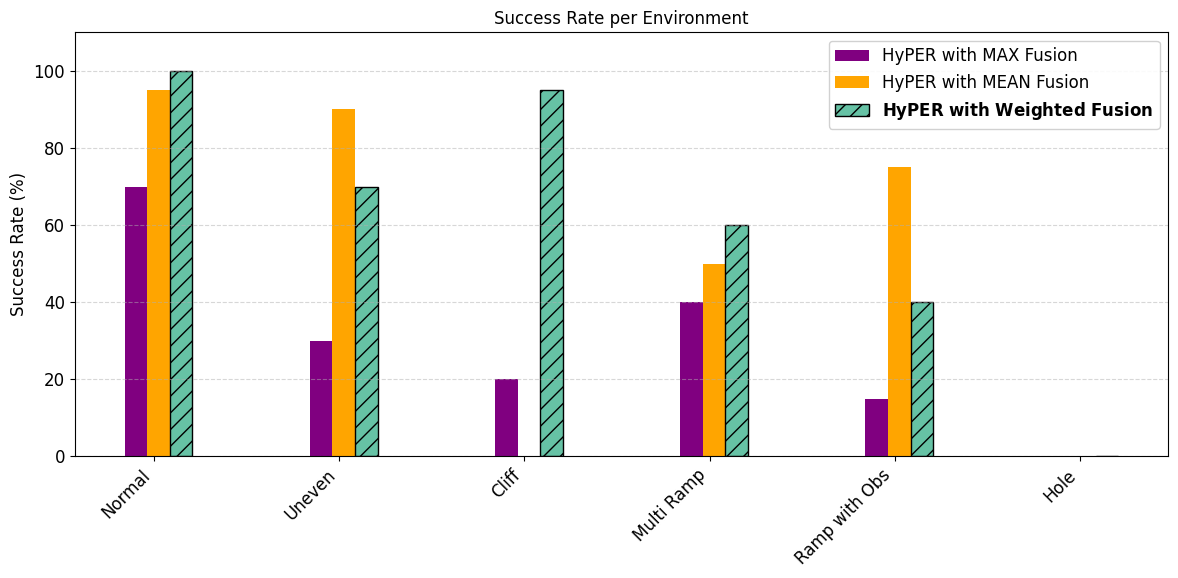

In [16]:

stats4_labeled = relabel_stats(stats4)
stats5_labeled = relabel_stats(stats5)
stats6_labeled = relabel_stats(stats6)  # <-- NEW

label_set = (
    set(stats4_labeled.keys())
    .union(stats5_labeled.keys())
    .union(stats6_labeled.keys())
)
all_labels = [lbl for lbl in desired_order if lbl in label_set] + sorted(label_set - set(desired_order))

# Build series

full_rates    = [stats4_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
test_rates    = [stats5_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
new_rates     = [stats6_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]  # <-- NEW
# Plotting
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing

width = 0.22  # Bar width

offsets = [
    -2.2 * width,  # STEP: Positioned further left
    -0.8 * width,  # RandLA: Start of the right group
     0.2 * width,  # Combine: Middle of the right group
     1.2 * width   # AWARE: End of the right group
]
plt.figure(figsize=(max(12, len(all_labels)*0.8), 6))

# Plotting the bars
plt.bar(x + offsets[1], full_rates,    width, label='HyPER with MAX Fusion', color='purple')
plt.bar(x + offsets[2], test_rates,    width, label='HyPER with MEAN Fusion', color='orange')
plt.bar(
    x + offsets[3],
    new_rates,
    width,
    # CHANGE: Add backslashes (\) before spaces to preserve them in bold math mode
    label=r'$\bf{HyPER\ with\ Weighted\ Fusion}$', 
    color='#66C2A5',
    edgecolor='black',
    hatch='//'  
)

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Success Rate (%)")
plt.ylim(0, 110)
plt.title("Success Rate per Environment")
plt.legend(ncol=1, loc='upper right', framealpha=0.9) 
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

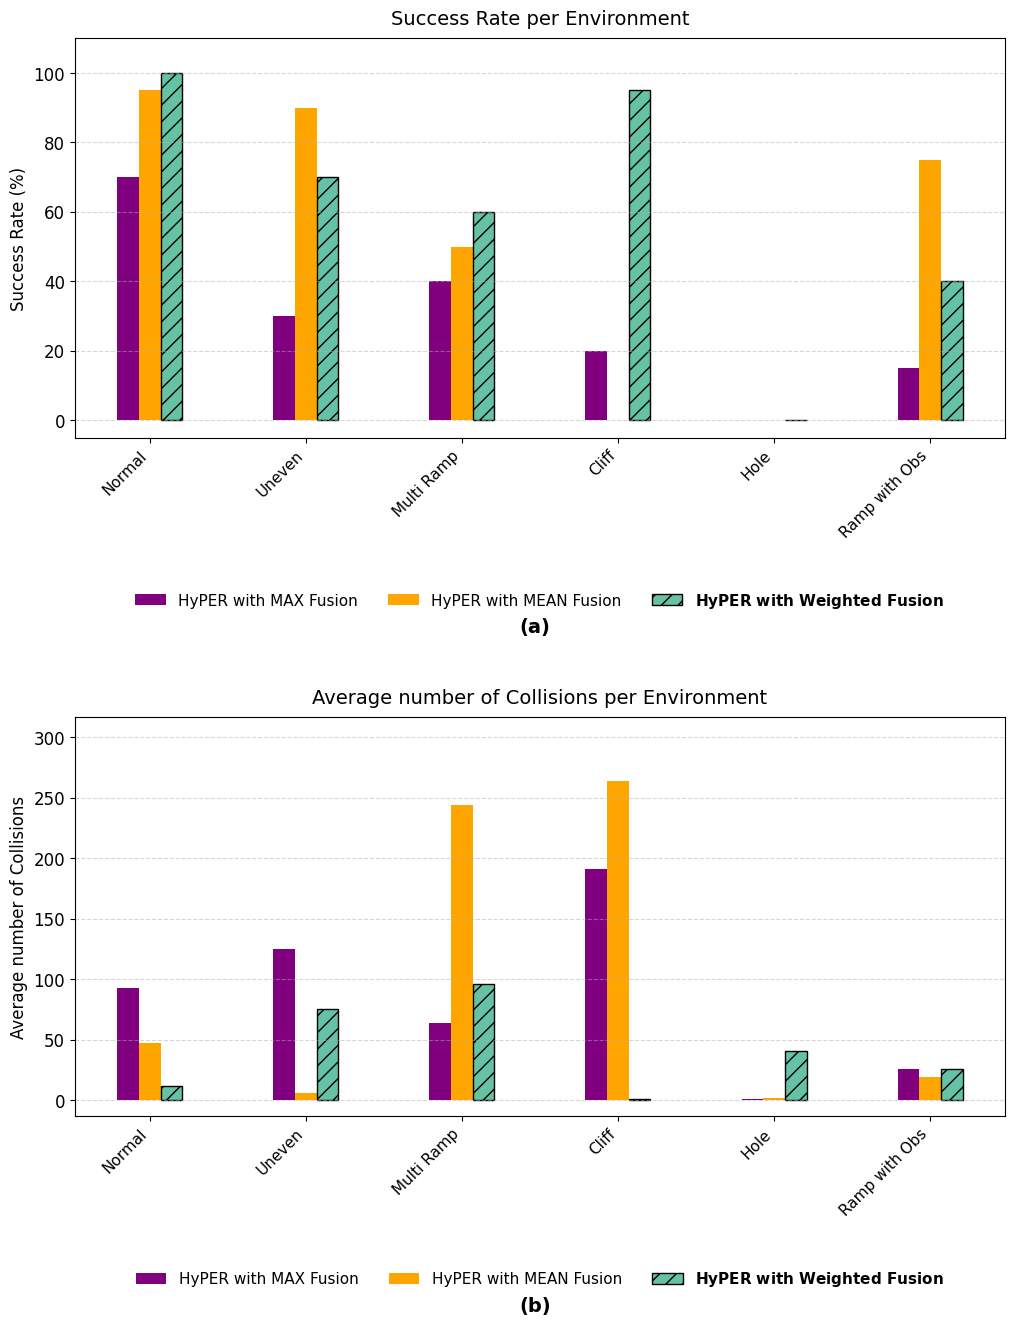

In [17]:
desired_order = ["Normal", "Uneven", "Multi Ramp", "Cliff", "Obstacle Ramp", "Hole"]

# BUILD LABEL SET
label_set = (
    set(stats4_labeled.keys())
    .union(stats5_labeled.keys())
    .union(stats6_labeled.keys())
)

# SORT LABELS
# Filter desired_order to only include labels that actually exist in the data
all_labels = [lbl for lbl in desired_order if lbl in label_set]
leftovers = sorted(list(label_set - set(all_labels)))
all_labels.extend(leftovers)

# DISPLAY LABELS
# Since relabel_stats already cleaned the names, we can use all_labels directly
# or apply simple title casing if needed.
display_labels = all_labels 

# Data Extraction
full_rates = [stats4_labeled.get(l, {}).get("reach_goal_rate", 0) for l in all_labels]
test_rates = [stats5_labeled.get(l, {}).get("reach_goal_rate", 0) for l in all_labels]
new_rates  = [stats6_labeled.get(l, {}).get("reach_goal_rate", 0) for l in all_labels]

full_cols  = [stats4_labeled.get(l, {}).get("collision_count", 0) for l in all_labels]
test_cols  = [stats5_labeled.get(l, {}).get("collision_count", 0) for l in all_labels]
new_cols   = [stats6_labeled.get(l, {}).get("collision_count", 0) for l in all_labels]

# LAYOUT SETUP
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing
width = 0.25

offsets = [-1.0 * width, 0.0 * width, 1.0 * width]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(12, len(all_labels)*1.0), 14))
plt.subplots_adjust(hspace=0.7)

# ==========================================
# SUBPLOT 1: SUCCESS RATE
# ==========================================
ax1.bar(x + offsets[0], full_rates, width, label='HyPER with MAX Fusion',  color='purple')
ax1.bar(x + offsets[1], test_rates, width, label='HyPER with MEAN Fusion', color='orange')
ax1.bar(x + offsets[2], new_rates,  width, label=r'$\bf{HyPER\ with\ Weighted\ Fusion}$ ', 
        color='#66C2A5', edgecolor='black', hatch='//')

ax1.set_xticks(x)
ax1.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=11)
ax1.set_ylabel("Success Rate (%)", fontsize=12)
ax1.set_title("Success Rate per Environment", fontsize=14, pad=10)

ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False, fontsize=11)
ax1.text(0.495, -0.45, "(a)", transform=ax1.transAxes, ha='center', va='top', fontsize=14, fontweight='bold')

ax1.set_ylim(-5, 110)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

# ==========================================
# SUBPLOT 2: COLLISIONS
# ==========================================
ax2.bar(x + offsets[0], full_cols, width, label='HyPER with MAX Fusion',  color='purple')
ax2.bar(x + offsets[1], test_cols, width, label='HyPER with MEAN Fusion', color='orange')
ax2.bar(x + offsets[2], new_cols,  width, label=r'$\bf{HyPER\ with\ Weighted\ Fusion}$', 
        color='#66C2A5', edgecolor='black', hatch='//')

ax2.set_xticks(x)
ax2.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=11)
ax2.set_ylabel("Average number of Collisions", fontsize=12)
ax2.set_title("Average number of Collisions per Environment", fontsize=14, pad=10)

ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False, fontsize=11)
ax2.text(0.495, -0.45, "(b)", transform=ax2.transAxes, ha='center', va='top', fontsize=14, fontweight='bold')

max_col_val = max(max(full_cols), max(test_cols), max(new_cols))
ax2.set_ylim(-max_col_val*0.05, max_col_val * 1.2)
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.savefig("figures/fusion_comparison.png", format="png", bbox_inches='tight')
plt.show()

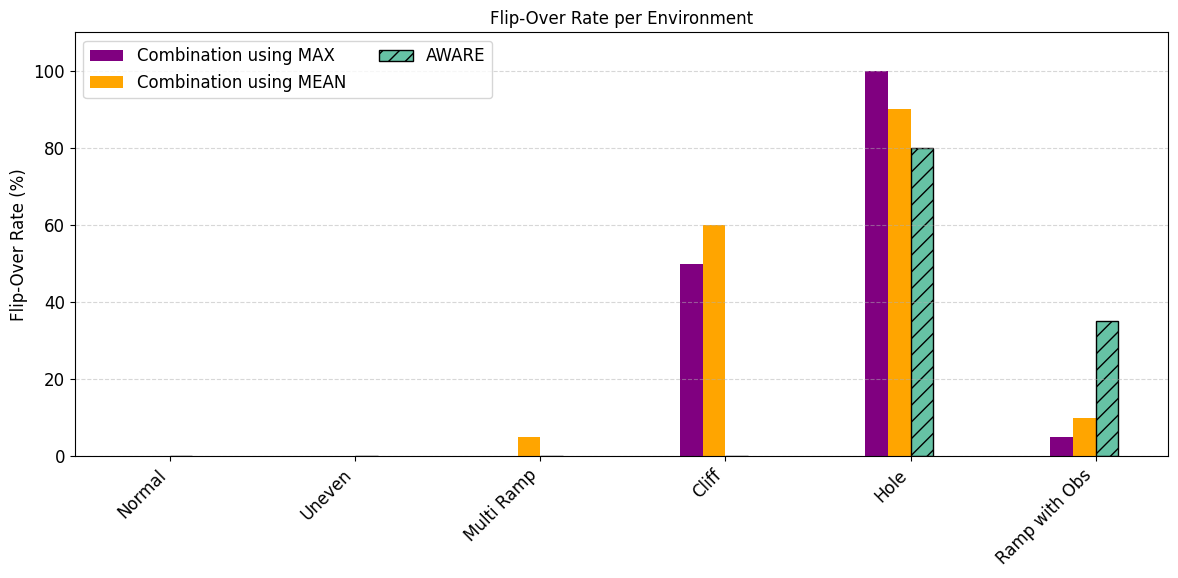

In [18]:
# Build flip-over series
full_flip    = [stats4_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]
test_flip    = [stats5_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]
new_flip     = [stats6_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]

# Plotting
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing

width = 0.22
offsets = [-2.5*width, -1.5*width, -0.5*width, 0.5*width, 1.5*width, 2.5*width]

plt.figure(figsize=(max(12, len(all_labels)*0.8), 6))

plt.bar(x + offsets[1], full_flip,    width, label='Combination using MAX ', color='purple')
plt.bar(x + offsets[2], test_flip,    width, label='Combination using MEAN', color='orange')
plt.bar(
    x + offsets[3],
    new_flip,
    width,
    label='AWARE',
    color='#66C2A5',
    edgecolor='black',hatch='//'  
)

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Flip-Over Rate (%)")
plt.ylim(0, 110)
plt.title("Flip-Over Rate per Environment")
plt.legend(ncol=2)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
